# **Attention Modeling**

1. In normal Seq2Seq, the encoder sends only one final vector to the decoder.

2. This can lose important information in long sentences.

3. Attention allows the decoder to look at all encoder outputs, not just the last one.

4. For each output word, the decoder calculates which input words are more important.

5. It gives higher weight to important words using softmax.

6. A weighted sum (context vector) is created.

7. This context vector helps predict the next word correctly.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt

1. Device Configuration

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# **2. Load CSV Dataset**

In [11]:
df = pd.read_csv("english_sanskrit_dataset.csv")

# Convert dataframe to list of sentence pairs
pairs = list(zip(df["english"], df["sanskrit"]))

# **3. Language Vocabulary Class**

In [12]:
class Lang:
    def __init__(self):
        # Special tokens
        self.word2index = {"<SOS>": 0, "<EOS>": 1}
        self.index2word = {0: "<SOS>", 1: "<EOS>"}
        self.n_words = 2

    def add_sentence(self, sentence):
        for word in sentence.split(' '):
            if word not in self.word2index:
                self.word2index[word] = self.n_words
                self.index2word[self.n_words] = word
                self.n_words += 1

input_lang = Lang()
output_lang = Lang()
for eng, san in pairs:
  input_lang.add_sentence(eng)
  output_lang.add_sentence(san)


# **4. Encoder Model**

In [13]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size):
        super(Encoder, self).__init__()

        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(input_size, hidden_size)
        self.gru = nn.GRU(hidden_size, hidden_size)

    def forward(self, input, hidden):
        # Convert word index to embedding vector
        embedded = self.embedding(input).view(1, 1, -1)

        # Pass through GRU
        output, hidden = self.gru(embedded, hidden)

        return output, hidden

# **5. Attention Decoder Model**

In [14]:
class AttnDecoder(nn.Module):
    def __init__(self, hidden_size, output_size, max_length=10):
        super(AttnDecoder, self).__init__()

        self.hidden_size = hidden_size
        self.output_size = output_size
        self.max_length = max_length

        self.embedding = nn.Embedding(output_size, hidden_size)

        # Attention layer
        self.attn = nn.Linear(hidden_size * 2, max_length)

        # Combine context + embedding
        self.attn_combine = nn.Linear(hidden_size * 2, hidden_size)

        self.gru = nn.GRU(hidden_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input, hidden, encoder_outputs):

        embedded = self.embedding(input).view(1, 1, -1)

        # Calculate attention weights
        attn_weights = F.softmax(
            self.attn(torch.cat((embedded[0], hidden[0]), 1)), dim=1
        )

        # Apply attention weights
        attn_applied = torch.bmm(
            attn_weights.unsqueeze(0),
            encoder_outputs.unsqueeze(0)
        )

        # Combine embedding + context
        output = torch.cat((embedded[0], attn_applied[0]), 1)
        output = self.attn_combine(output).unsqueeze(0)

        output = F.relu(output)
        output, hidden = self.gru(output, hidden)

        # Final output
        output = F.log_softmax(self.out(output[0]), dim=1)

        return output, hidden, attn_weights


# **6. Training Function**

In [15]:
def train(input_tensor, target_tensor,
          encoder, decoder,
          encoder_optimizer, decoder_optimizer,
          criterion, max_length=10):

    encoder_hidden = torch.zeros(1, 1, encoder.hidden_size, device=device)

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    input_length = input_tensor.size(0)
    target_length = target_tensor.size(0)

    encoder_outputs = torch.zeros(max_length,
                                  encoder.hidden_size,
                                  device=device)

    loss = 0

    # Encode input sentence
    for ei in range(input_length):
        encoder_output, encoder_hidden = encoder(
            input_tensor[ei], encoder_hidden)
        encoder_outputs[ei] = encoder_output[0, 0]

    # Decoder starts with <SOS>
    decoder_input = torch.tensor([[0]], device=device)
    decoder_hidden = encoder_hidden

    # Teacher forcing
    for di in range(target_length):
        decoder_output, decoder_hidden, _ = decoder(
            decoder_input, decoder_hidden, encoder_outputs)

        loss += criterion(decoder_output, target_tensor[di].unsqueeze(0))
        decoder_input = target_tensor[di]

    # Backpropagation
    loss.backward()

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length


# **7. Evaluation + Attention Plot**

In [16]:
def evaluate_and_show_attention(encoder, decoder, sentence, max_length=10):

    with torch.no_grad():

        input_tensor = torch.tensor(
            [input_lang.word2index[w] for w in sentence.split(' ')],
            device=device)

        input_length = input_tensor.size(0)

        encoder_hidden = torch.zeros(1, 1,
                                     encoder.hidden_size,
                                     device=device)

        encoder_outputs = torch.zeros(max_length,
                                      encoder.hidden_size,
                                      device=device)

        for ei in range(input_length):
            encoder_output, encoder_hidden = encoder(
                input_tensor[ei], encoder_hidden)
            encoder_outputs[ei] = encoder_output[0, 0]

        decoder_input = torch.tensor([[0]], device=device)
        decoder_hidden = encoder_hidden

        decoded_words = []
        decoder_attentions = torch.zeros(max_length, max_length)

        for di in range(max_length):
            decoder_output, decoder_hidden, decoder_attention = decoder(
                decoder_input, decoder_hidden, encoder_outputs)

            decoder_attentions[di] = decoder_attention.data

            topv, topi = decoder_output.data.topk(1)

            if topi.item() == 1:  # EOS
                break
            else:
                decoded_words.append(
                    output_lang.index2word[topi.item()]
                )

            decoder_input = topi.squeeze().detach()

        print("Input:", sentence)
        print("Translation:", " ".join(decoded_words))

        # Plot Attention Heatmap
        plt.figure()
        plt.matshow(decoder_attentions[:di+1, :input_length].cpu().numpy())
        plt.show()


# **8. Model Initialization**

In [17]:
hidden_size = 256

encoder = Encoder(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoder(hidden_size, output_lang.n_words).to(device)

encoder_optimizer = optim.SGD(encoder.parameters(), lr=0.01)
decoder_optimizer = optim.SGD(decoder.parameters(), lr=0.01)

criterion = nn.NLLLoss()

print("Training Started...")

Training Started...


# **9. Training Loop**

In [18]:
for epoch in range(5):
    total_loss = 0
    for eng, san in pairs:

        input_tensor = torch.tensor(
            [input_lang.word2index[w] for w in eng.split(' ')],
            device=device)

        target_indexes = [output_lang.word2index[w] for w in san.split(' ')]
        target_indexes.append(output_lang.word2index["<EOS>"])

        target_tensor = torch.tensor(target_indexes, device=device)

        loss = train(input_tensor, target_tensor,
                     encoder, decoder,
                     encoder_optimizer,
                     decoder_optimizer,
                     criterion)

        total_loss += loss

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(pairs)}")

print("Training Complete!")

Epoch 1, Loss: 1.103599918273588
Epoch 2, Loss: 0.07468134349212051
Epoch 3, Loss: 0.019777609566226602
Epoch 4, Loss: 0.010956944729356715
Epoch 5, Loss: 0.0074482122463329385
Training Complete!


# **10. Test Translation**

Input: i am a student
Translation: अहम् छात्रः अस्मि


<Figure size 640x480 with 0 Axes>

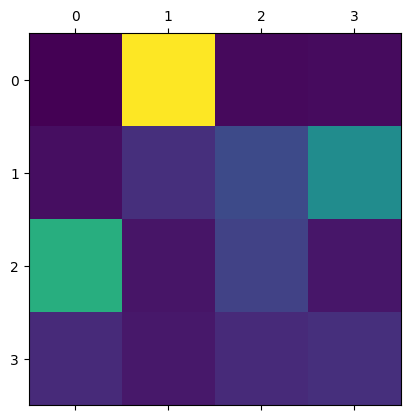

In [19]:
evaluate_and_show_attention(
    encoder, decoder,
    "i am a student"
)